# **Modul Praktik 2: Predictive Analytics untuk Customer Churn**
## **Studi Kasus:** Industri Telekomunikasi (Memprediksi pelanggan yang akan berhenti berlangganan).
**Tujuan Bisnis:** Mengidentifikasi pelanggan berisiko tinggi agar tim Marketing bisa memberikan promo penahanan (retention program) secara tepat sasaran, alih-alih membakar uang dengan memberi promo ke semua orang.

In [1]:
# MENGINSTAL LIBRARY TAMBAHAN
# Di industri, kita butuh tool yang cepat untuk modeling (XGBoost) dan pembuatan UI/Dashboard (Gradio)
!pip install xgboost gradio -q

# **Tahap 1: Ingestion & Persiapan Library**
Kita akan memuat data dari cloud (GitHub) dan menyiapkan library standar industri untuk manipulasi data (Pandas) dan Machine Learning (Scikit-Learn & XGBoost).

Dataset :
https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

In [2]:
# IMPORT LIBRARY STANDAR INDUSTRI
import pandas as pd                  # Untuk manipulasi data tabular (seperti Excel)
import numpy as np                   # Untuk komputasi numerik
import matplotlib.pyplot as plt      # Untuk visualisasi dasar
import seaborn as sns                # Untuk visualisasi yang lebih rapi
from sklearn.model_selection import train_test_split # Membagi data Train/Test
from sklearn.metrics import classification_report    # Laporan evaluasi model
from sklearn.ensemble import RandomForestClassifier  # Model Machine Learning 1
from xgboost import XGBClassifier                    # Model Machine Learning 2 (Sering juara di Kaggle)
import gradio as gr                  # Untuk membuat Web UI instan
import warnings
warnings.filterwarnings('ignore')    # Menyembunyikan peringatan/warning agar tampilan bersih

# 1. MEMUAT DATASET
# Menarik data historis pelanggan langsung dari repository
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Total Data Pelanggan: {df.shape[0]} baris, {df.shape[1]} kolom")
# Melihat 5 baris pertama data untuk memastikan struktur data sudah benar
df.head()

Total Data Pelanggan: 7043 baris, 21 kolom


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Tahap 2: Data Preparation (Pembersihan Data)**
Di dunia nyata, data tidak pernah 100% bersih. Model Machine Learning hanya bisa membaca angka, sehingga kita harus:

1.   Membuang kolom yang tidak punya nilai prediktif (seperti ID Pelanggan)
2. Memperbaiki tipe data yang salah (misal: angka yang terbaca sebagai teks).
3. Mengubah data kategori (Teks) menjadi angka (One-Hot Encoding).

In [3]:
# 1. MEMBUANG DATA TIDAK RELEVAN
# customerID tidak punya pola prediktif, kalau dimasukkan malah membuat model 'bingung'
df = df.drop('customerID', axis=1)

# 2. MENANGANI MISSING VALUES & TIPE DATA
# TotalCharges (Total Tagihan) kadang terbaca sebagai teks (' ') jika pelanggan baru daftar.
# Kita paksa jadi numerik (errors='coerce' mengubah error jadi NaN/Kosong), lalu isi yang kosong dengan nilai Tengah (Median).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 3. MENGUBAH TARGET JADI BINER (0 dan 1)
# Komputer lebih paham 1 untuk 'Iya (Churn)' dan 0 untuk 'Tidak'
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Memisahkan Fitur (X) sebagai bahan belajar, dan Target (y) sebagai jawaban
X = df.drop('Churn', axis=1)
y = df['Churn']

# 4. ENCODING FITUR KATEGORIKAL (Teks ke Angka)
# pd.get_dummies akan membuat kolom baru untuk setiap kategori (misal: Gender_Male, Gender_Female)
# drop_first=True digunakan untuk mencegah redundansi data (Multikolinearitas)
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. MEMBAGI DATA (TRAIN vs TEST)
# 80% data untuk model belajar (Train), 20% untuk ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Jumlah Data Latih (Train):", X_train.shape[0])
print("Jumlah Data Uji (Test):", X_test.shape[0])

Jumlah Data Latih (Train): 5634
Jumlah Data Uji (Test): 1409


# **Tahap 3: Quick Exploratory Data Analysis (EDA)**
Sebelum memodelkan, kita harus tahu **"Apa alasan utama pelanggan kabur?"**
Kita gunakan uji Korelasi. Nilai positif artinya fitur tersebut mendorong pelanggan untuk Churn. Nilai negatif artinya fitur tersebut menahan pelanggan untuk tetap tinggal.

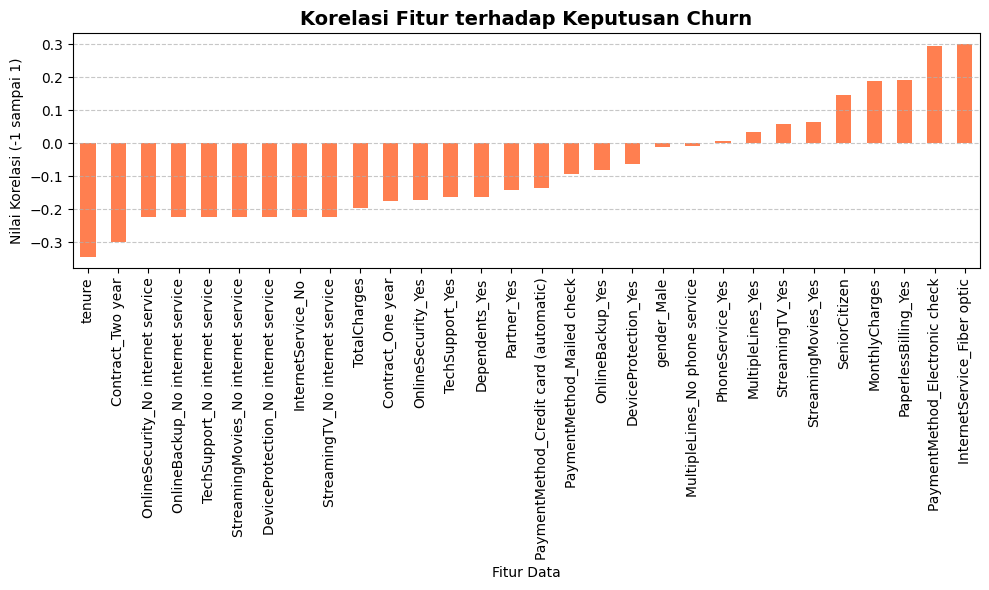

In [4]:
# Menghitung korelasi tiap fitur terhadap status Churn
plt.figure(figsize=(10,6))
# Menggabungkan X_train dan y_train sementara untuk menghitung korelasi, lalu di-plot bar chart
X_train.assign(Churn=y_train).corr()['Churn'].sort_values()[:-1].plot(kind='bar', color='coral')

plt.title("Korelasi Fitur terhadap Keputusan Churn", fontsize=14, fontweight='bold')
plt.ylabel("Nilai Korelasi (-1 sampai 1)")
plt.xlabel("Fitur Data")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# INSIGHT BISNIS DARI GRAFIK:
# 1. "Contract_Two_year" (kiri bawah) sangat negatif: Pelanggan kontrak panjang sangat setia.
# 2. "Contract_Month-to-month" (kanan atas) sangat positif: Pelanggan tanpa ikatan/bulanan sangat rawan kabur!

## **📊 Insight Bisnis: Membaca Faktor Pendorong & Penahan Churn**
Berdasarkan grafik korelasi pada diagram batang, kita bisa membagi temuan menjadi dua kategori utama. **Nilai negatif** (kiri) adalah faktor loyalitas (membuat pelanggan bertahan), sedangkan **nilai positif** (kanan) adalah faktor risiko (mendorong pelanggan untuk kabur).

## **🛡️ Faktor Penahan (Korelasi Negatif / Mengurangi Risiko Churn)**
Fitur-fitur ini adalah "jangkar" yang membuat pelanggan enggan berpindah ke kompetitor:

**tenure (Lama Berlangganan):** Memiliki korelasi negatif terkuat (sekitar -0.35). Semakin lama seseorang menjadi pelanggan, semakin kecil kemungkinan mereka untuk churn.

**Contract_Two year (Kontrak 2 Tahun):** Mengunci pelanggan dengan kontrak jangka panjang terbukti sangat efektif menekan angka churn.

**Layanan Ekstra (OnlineSecurity_Yes, TechSupport_Yes):** Pelanggan yang membeli layanan keamanan dan dukungan teknis cenderung lebih setia. Ini menunjukkan bahwa rasa aman dan pelayanan pelanggan (customer support) yang baik adalah kunci retensi.

## **⚠️ Faktor Pendorong (Korelasi Positif / Meningkatkan Risiko Churn)**
Fitur-fitur ini adalah "lampu merah" yang harus segera diinvestigasi oleh tim produk dan bisnis:

**InternetService_Fiber optic:** Memiliki korelasi positif tertinggi (sekitar +0.30). Ini temuan yang menarik! Pelanggan layanan Fiber Optic justru paling banyak kabur. Hipotesis Bisnis: Apakah harganya terlalu mahal? Apakah koneksinya sering putus? Atau kompetitor menawarkan Fiber Optic yang jauh lebih murah? Tim bisnis harus segera mengevaluasi produk ini.

**PaymentMethod_Electronic check:** Pelanggan yang membayar menggunakan Electronic check sangat rawan churn. Hipotesis Bisnis: Mungkin proses pembayarannya rumit atau sering error. Mendorong pelanggan beralih ke Credit card (automatic) bisa menjadi solusi taktis.

**MonthlyCharges (Tagihan Bulanan):** Semakin tinggi tagihan bulanan, semakin tinggi probabilitas pelanggan untuk berhenti. Ini adalah perilaku konsumen yang sangat wajar (sensitivitas harga).

## **💡 Rekomendasi Strategi untuk Manajemen:**

**Fokus pada Up-Selling Layanan:** Tawarkan diskon bundel untuk fitur Online Security dan Tech Support kepada pelanggan baru.

**Evaluasi Produk Fiber Optic:** Segera lakukan survei kepuasan pelanggan khusus untuk pengguna Fiber Optic untuk mengetahui pain points mereka.

**Migrasi Metode Pembayaran:** Buat campaign promo (misal: "Diskon 5% untuk 3 bulan pertama") bagi pelanggan yang mau mengubah metode pembayaran mereka dari Electronic check ke Auto-debit atau Kartu Kredit.

# **Tahap 4: Pelatihan & Perbandingan Model ML**
Kita membandingkan **Random Forest**(algoritma klasik yang stabil) dengan **XGBoost**(algoritma gradient boosting modern yang sering menang di kompetisi data sains).
Kita akan fokus melihat metrik Recall untuk kelas 1 (Churn), karena secara bisnis lebih baik kita salah mendeteksi pelanggan mau kabur, daripada kelewatan pelanggan yang beneran kabur.

In [12]:
# 1. INISIASI MODEL (Membuat 'otak' kosong)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# XGBoost butuh parameter use_label_encoder=False agar tidak muncul warning di versi terbaru
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 2. TRAINING MODEL (Proses Belajar)
# Model belajar mencari pola dari X_train untuk menebak y_train
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 3. PREDIKSI DATA UJIAN
# Menguji kepintaran model menggunakan data X_test yang belum pernah ia lihat
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# 4. EVALUASI HASIL (Mencetak Rapor)
print("="*40)
print("   PERFORMA RANDOM FOREST")
print("="*40)
print(classification_report(y_test, rf_pred))

print("\n" + "="*40)
print("      PERFORMA XGBOOST")
print("="*40)
print(classification_report(y_test, xgb_pred))

# DISKUSI KELAS:
# Perhatikan nilai 'Recall' pada baris angka '1'.
# Mana model yang lebih banyak 'menangkap' pelanggan yang beneran churn? Itulah yang kita pilih.

   PERFORMA RANDOM FOREST
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409


      PERFORMA XGBOOST
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.64      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



## **📈 Penjelasan Performa: Mengapa XGBoost Menang?**
Jika kita hanya melihat **Accuracy (Akurasi)**, kedua model tampak seimbang di angka 79% (0.79). Namun, di dunia industri, akurasi sering kali menjadi jebakan (Accuracy Trap), terutama saat **data tidak seimbang (imbalanced data)** seperti ini (1036 tidak churn vs 373 churn).

Fokus utama bisnis kita adalah Kelas 1 (Pelanggan yang Churn). Mari kita bedah metriknya:

### **Precision (Presisi) pada Kelas 1 - [RF: 0.64 | XGB: 0.64]**

Arti Bisnis: Dari semua pelanggan yang "dituduh" akan kabur oleh model, berapa persen yang beneran kabur? Keduanya mencapai 64%. Artinya, jika tim marketing memberi diskon ke 100 orang berdasarkan prediksi model, 64 orang tepat sasaran, 36 orang lainnya sebenarnya tidak niat kabur (pemborosan anggaran).

### **Recall (Sensitivitas) pada Kelas 1 - [RF: 0.46 | XGB: 0.52] 🏆**

Arti Bisnis: Dari TOTAL SELURUH pelanggan yang benar-benar kabur di dunia nyata (373 orang), berapa banyak yang berhasil "ditangkap" oleh sistem?

**Random Forest hanya menangkap 46%, sisanya lolos (kerugian besar!).**

**XGBoost berhasil menangkap 52%.**

**Kesimpulan Bisnis: Kita memilih XGBoost.**

# **Tahap 5: Deployment Sederhana (Pembuatan Aplikasi Interaktif)**
Di industri, model ML berupa kode Python tidak bisa dipakai oleh manajer atau tim Customer Service.
Kita akan menyulap model **XGBoost** kita menjadi sebuah Web Aplikasi interaktif menggunakan **Gradio.**

In [16]:
# 1. MEMBUAT FUNGSI LOGIKA PREDIKSI
def predict_churn(tenure, MonthlyCharges, TotalCharges, Contract):
    """
    Fungsi ini akan menerima input dari Web UI, mengubahnya jadi format
    yang dimengerti model, lalu mengeluarkan hasil prediksi.
    """
    # Menyiapkan 'blueprint' data kosong yang bentuknya persis seperti data training (X_train)
    blueprint = pd.DataFrame(columns=X_train.columns)
    blueprint.loc[0] = 0 # Isi awal dengan angka 0 semua

    # Memasukkan inputan user dari UI ke dalam blueprint
    blueprint['tenure'] = tenure
    blueprint['MonthlyCharges'] = MonthlyCharges
    blueprint['TotalCharges'] = TotalCharges

    # Logika One-Hot Encoding manual untuk tipe kontrak
    if Contract == 'One year':
        blueprint['Contract_One year'] = 1
    elif Contract == 'Two year':
        blueprint['Contract_Two year'] = 1
    # Note: Jika Month-to-month, semua kolom contract bernilai 0 (sesuai efek drop_first=True di awal)

    # Meminta XGBoost memprediksi PROBABILITAS (peluang) churn
    # predict_proba menghasilkan [peluang_tidak_churn, peluang_churn]
    prob = xgb_model.predict_proba(blueprint)[0][1]

    # Menerjemahkan angka probabilitas menjadi bahasa bisnis
    if prob > 0.5:
        return f"🚨 RISIKO TINGGI: Pelanggan diprediksi CHURN ({prob*100:.1f}%).\nSaran Bisnis: Segera tawarkan diskon atau perpanjangan kontrak!"
    else:
        return f"✅ AMAN: Pelanggan diprediksi SETIA (Risiko hanya {prob*100:.1f}%).\nSaran Bisnis: Pertahankan pelayanan standar."

# 2. MEMBANGUN ANTARMUKA WEB (UI)
interface = gr.Interface(
    fn=predict_churn, # Fungsi yang dipanggil saat tombol di-klik
    inputs=[
        # Menyiapkan elemen input (Slider, Angka, Pilihan)
        gr.Slider(minimum=0, maximum=72, value=12, label="Lama Berlangganan (Bulan)"),
        gr.Number(value=50.0, label="Tagihan Bulanan ($)"),
        gr.Number(value=600.0, label="Total Tagihan Sejauh Ini ($)"),
        gr.Radio(["Month-to-month", "One year", "Two year"], label="Tipe Kontrak Saat Ini")
    ],
    outputs=gr.Text(label="Rekomendasi AI"),
    title="Dashboard AI - Prediksi Retensi Pelanggan",
    description="Tool interaktif untuk Tim Customer Success. Ubah parameter pelanggan di bawah ini untuk melihat estimasi risiko Churn secara real-time.",
    theme="default"
)

# 3. MENJALANKAN APLIKASI
# share=True akan membuatkan Link URL Publik (berlaku 72 jam) yang bisa diakses via HP
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d4eafcfdfc8861b4c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Tahap 6 (Alternatif): Export Model & Web App dengan Streamlit**

Selain Gradio, industri sering menggunakan Streamlit untuk membangun dashboard internal yang lebih fleksibel. Pada tahap ini, kita akan menyimpan "otak" model kita ke dalam format file .pkl agar bisa dibawa keluar dari Colab, lalu kita buatkan aplikasi Streamlit-nya.

In [14]:
import pickle

# Menyimpan model XGBoost yang sudah dilatih ke dalam file .pkl
model_filename = 'xgb_churn_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(xgb_model, file)

print(f"✅ Model berhasil disimpan sebagai: {model_filename}")
# Anda bisa mendownload file ini dari panel 'Files' di sebelah kiri Colab

✅ Model berhasil disimpan sebagai: xgb_churn_model.pkl


In [15]:
# MENGGUNAKAN CARA NATIVE XGBOOST
model_filename = 'xgb_churn_model.json' # Ubah ekstensi jadi .json
xgb_model.save_model(model_filename)

print(f"✅ Model berhasil disimpan sebagai: {model_filename}")

✅ Model berhasil disimpan sebagai: xgb_churn_model.json


### **💻 Alternatif: Menjalankan Web App Secara Lokal (Offline di PC)**
Jika Anda mengalami kendala jaringan dengan localtunnel, kita bisa memindahkan "otak" AI yang sudah kita latih di cloud (Colab) ke komputer pribadi Anda. Ini adalah simulasi nyata bagaimana sebuah model di-deploy ke server internal perusahaan.

**Langkah 1: Unduh File dari Google Colab**
1. Di Google Colab, lihat menu panel di sebelah kiri layar, klik ikon Folder (Files).

2. Cari file xgb_churn_model.pkl (Model ML) dan app.py (Kode UI Streamlit yang barusan dibuat).

3. Klik titik tiga pada masing-masing file tersebut, lalu pilih Download.

4. Buat sebuah folder baru di PC/Laptop Anda (misal: C:\Project_Churn\), lalu pindahkan kedua file yang baru diunduh ke dalam folder tersebut.

**Langkah 2: Persiapan Lingkungan di PC (Terminal/Command Prompt)**
Pastikan komputer Anda sudah terinstal Python. Buka Command Prompt (CMD) di Windows atau Terminal di Mac/Linux, lalu arahkan ke folder tempat Anda menyimpan file tadi:

*> Pindah ke direktori folder Anda*

`cd C:\Project_Churn\`

Selanjutnya, install library yang dibutuhkan oleh aplikasi kita agar bisa berjalan di komputer lokal:


*> Menginstal Streamlit dan library data science pendukung*

`pip install streamlit pandas xgboost scikit-learn`


**Langkah 3: Jalankan Aplikasi Streamlit**
Setelah proses instalasi selesai, ketik perintah sakti ini di CMD/Terminal :


`streamlit run app.py`


**Apa yang akan terjadi?**

Terminal akan memproses perintah tersebut dan menampilkan pesan You can now view your Streamlit app in your browser.

Browser bawaan Anda (Chrome/Edge/Safari) akan otomatis terbuka dan mengarah ke alamat lokal: http://localhost:8501.

Aplikasi Prediksi Retensi Pelanggan Anda sekarang berjalan secara offline dan super cepat di PC Anda, bebas dari pemblokiran firewall atau kendala internet!

## **💡 Pesan untuk Tim IT/DevOps:**
File app.py dan xgb_churn_model.pkl ini adalah bentuk paling mentah dari sebuah Microservice. Di tahap production yang sebenarnya, kedua file ini biasanya akan dibungkus menggunakan Docker, lalu diunggah ke Cloud Server (seperti AWS, GCP, atau server internal perusahaan) agar bisa diakses oleh seluruh tim Customer Service melalui jaringan intranet.

In [10]:
# cek versi xgboost yang digunakan google colab
import xgboost
print(xgboost.__version__)

3.3.0


Jika ada masalah incompatibilitas versi XGBoost, gunakan perintah ini untuk menyesuaikan dengan versi XGBoost Google Colab

`pip install xgboost==[versi xgboost google colab]`

### **Kode app.py yang dijalankan lokal**


```
import streamlit as st
import pandas as pd
import xgboost as xgb  # <-- PERUBAHAN  jika menggunakan format .json
# import pickle  # <-- PERUBAHAN jika menggunakan format .pkl
# import joblib  #<--- perubahan jika menggunakan model .joblib

# 1. Load Model yang sudah disave menggunakan format JSON
model = xgb.XGBClassifier()             # <-- PERUBAHAN 2: Inisiasi otak model kosong
model.load_model('xgb_churn_model.json') # <-- PERUBAHAN 3: Isi otak dengan file json
# model = pickle.load(open('xgb_churn_model.pkl', 'rb')) #<--- perubahan jika menggunakan model .pkl
# model = joblib.load('rf_churn_model.pkl')  #<--- perubahan jika menggunakan model .joblib

# Dummy blueprint kolom X_train (pastikan urutan sama saat training)
# (Di real-project, blueprint ini juga di-save sebagai .pkl)
# Dummy blueprint kolom X_train yang sudah diurutkan sesuai dengan harapan model
kolom_fitur = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male',
    'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service',
    'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No',
    'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
    'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes',
    'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service',
    'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes',
    'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
    'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

# 2. Desain UI Aplikasi Web
st.set_page_config(page_title="Prediksi Churn", layout="centered")
st.title("📊 Aplikasi Prediksi Retensi Pelanggan")
st.write("Masukkan data pelanggan di bawah ini untuk melihat probabilitas *Churn*.")

# Input Form
with st.form("form_prediksi"):
    col1, col2 = st.columns(2)
    
    with col1:
        tenure = st.number_input("Lama Berlangganan (Bulan)", min_value=0, max_value=72, value=12)
        MonthlyCharges = st.number_input("Tagihan Bulanan ($)", min_value=0.0, value=50.0)
        TotalCharges = st.number_input("Total Tagihan ($)", min_value=0.0, value=600.0)
        
    with col2:
        Contract = st.selectbox("Tipe Kontrak", ["Month-to-month", "One year", "Two year"])
        Internet = st.selectbox("Layanan Internet", ["DSL", "Fiber optic", "No"])
        
    submit = st.form_submit_button("Prediksi Risiko")

# 3. Logika Prediksi ketika tombol ditekan
if submit:
    # Buat dataframe kosong 1 baris
    df_input = pd.DataFrame(columns=kolom_fitur)
    df_input.loc[0] = 0 # Set default 0
    
    # Isi dengan nilai dari UI
    df_input['tenure'] = tenure
    df_input['MonthlyCharges'] = MonthlyCharges
    df_input['TotalCharges'] = TotalCharges
    
    # Mapping Dropdown ke format One-Hot Encoding
    if Contract == 'One year': df_input['Contract_One year'] = 1
    if Contract == 'Two year': df_input['Contract_Two year'] = 1
    if Internet == 'Fiber optic': df_input['InternetService_Fiber optic'] = 1
    if Internet == 'No': df_input['InternetService_No'] = 1
    
    # Lakukan Prediksi (Ambil probabilitas kelas 1 / Churn)
    prob_churn = model.predict_proba(df_input)[0][1]
    
    # Tampilkan Hasil
    st.markdown("---")
    if prob_churn > 0.5:
        st.error(f"🚨 **RISIKO TINGGI!** Pelanggan diprediksi CHURN dengan probabilitas {prob_churn*100:.2f}%")
        st.write("💡 *Saran: Segera jadwalkan panggilan dari Tim Retention.*")
    else:
        st.success(f"✅ **AMAN.** Probabilitas churn hanya {prob_churn*100:.2f}%")
        st.write("💡 *Saran: Pelanggan loyal, tidak perlu intervensi khusus.*")
```

